In [1]:
%matplotlib inline

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
import src.tetraphymac.logical_channels as lc
import src.tetraphymac.physical_channels as pc
import src.tetraphymac.modulation as tetraMod
from numpy import pi as pi
from numpy import complex64, int16, float64, uint8, cos, sin, log10
from numpy.typing import NDArray

# Propagation Models
There are 4 types of propagation models defined in 392-2 V2.4.2:
1. STATIC
2. TU50
3. HT200
4. EQ200
   
MS equipment falls into 3 classes
1. Class B: Equipment for built-up/urban areas, meeting Static and TU50
2. Class A: Equipment optimized for urban areas and hilly/mountainous terian meeting: Static, TU50, HT200
3. Class E: Equipment contains an equalizer (not BS equipment), specified for Static, TU50, HT200 (PACQ only), and EQ200 conditions

Specific performance requirements based on burst type apply for MER and BER for confromance/meeting propagation types for a given class.

## TETRA implementation
Since all the propagation models are defined in a similar way: delay, scale, tap-gain-process,
a generic propagation model class can be designed as follows:
1. Propagation Model
    1. Tap #1
        1. Delay Filter and/or Ampltiude scaling: a1*H1(t), (if delay is zero H(t) is 1)
        2. Tap-Gain-Process S1(t)
    2. Tap #2
       1. Delay Filter and/or Ampltiude scaling: a1*H2(t), (if delay is zero H(t) is 1)
       2. Tap-Gain-Process S2(t)
    3. Tap #N ...

With an input signal of x(t), the output is:
$$y(t)= \sum_{k=1}^{N}S_{k}(t)\times [x(t)\ast (a_{n}\times H_{n}(t))]$$

Note that the convolution/filtering result is delay compared to the original signal with zeros infront, and the output is fully flushed with zeros, thus leading to an output that is longer than the input which.

# Tap Gain Process Implementation
The specification denotes that for a CLASS type tap-gain-process or tgp for short, the resulting PSD follows the classic Clark's/Jake's "U" shaped doppler spectrum, which is well known.

This PSD arrises from the idea that the received signal can be thought of as purely multi-path, no LOS component, and comprised of the combination of numerous mutlipath rays coming all directions off of many reflecting of numerous objects from isotropic scattering. The resulting signal at the receiver is the combination of all these plane waves and thus has real and imaginary components which are uncorrelated zero mean (because no LOS) gaussian random variables. 

Thus the channel envelope has a rayleigh PDF, because it is the magnitude of a complex number whoses components are indepdent, zero mean. The amount of doppler shift then affects the speed/variability, in turn the coherence time, in the fading as well the PSD width/shape.

## Implementing tap-gain-process / rayleigh fading
There are a few ways to generate the tap-gain-process, but a simple, well behaved deterministic version has been developed though the sum of sinusoids. This method is deterministic and has been improved over time from Jake's original implementation to improve the statistics to agree better with the expected. There are some newer alternative versions optimized for hardware implementation, but the method developed by Zheng and Xiao in `Improved Models for the Generation of Multiple Uncorrelated Rayleigh Fading Waveforms`, 2002, is sufficent for this application. The basis is a complex gain of Z(t) is as follows taken from Zheng and Xiao:
$$ Z(t) = Z_c(t) + jZ_s(t)$$
$$Z_c(t) = \sqrt{\frac{2}{M}}\sum_{n=1}^{n=1M}cos(\omega_dtcos(\alpha_n)+ \phi_n)$$
$$Z_s(t) = \sqrt{\frac{2}{M}}\sum_{n=1}^{M}sin(\omega_dtsin(\alpha_n)+ \varphi_n)$$
$$\alpha_n = \frac{2\pi n-\pi+\theta }{4M},   n=1,2,...,M$$
- with uniform indepedent random variables: $\theta, \phi_n, \varphi_n$, distrubuted on: $[-\pi, \pi)$
- Higher M values improve the agreeance between the resulting statistics and PSD and the expected at the cost of computation amount.

## Sampling the process
Since the coherence time is quite slow compared to sample period of 11.52Msps, sampling at full rate is very wasteful, instead if we sample at a lower rate then perform progressive upsampling and filtering we can control the rejection of spectral images will still being efficent with polyphase filtering.
- spectral image rejection is very much a concern in upsampling/interpolation of the complex gain signal, this is because as a complex gain the resulting spectral images modulate with the baseband signal producing sidebands.
- So despite the statistics of the resulting interpolated signal match fairly well with the expected, a crossmodulation products close to the signal of interest are not at all desireable and can affect receiver performance in an unrealistic way

Therefore the following stages are employed:
1. Sample at 80khz, this is still very wasteful compared to the coherence time but provides a reasonable base sampling rate to work with in designing filters without need more cascaded stages
2. Upsample by x12 and filter with polyphase `sp.signal.upfirdn` and 4096 tap filter providing ~90dB of rejection at f>20khz
3. Upsample by x12 and filter again, with 4096 tap filter providing an additional ~90db of rejection at 48khz, thus 180db rejection of 80khz spectral images, and 100db of rejection of 960khz
4. Apply a 128 tap cleanup fir to provide an additional 50db of rejection, total of ~150db of rejection at spectral images of n*960khz


In [3]:
def class_PDS(f, fd):
    fd = float(fd)
    results = np.zeros_like(f, dtype=np.float64)
    mask = np.abs(f) < fd
    x = f[mask]/fd
    x = np.clip(x, -1 + 1e-12, 1 - 1e-12)
    results[mask] = 1/(pi * fd * np.sqrt(1 - (x*x)))
    return results

In [4]:
def get_fd(freq, mode: str, v: float | None = None):
    wl = (3E8/ freq)  # lambda/wavelength in Meters
    if mode == "STATIC":
        assert v is not None
        fd = (v / 3.6) / wl  # Hz
    else:
        assert mode in ("STATIC", "TU50", "HT200", "EQ200")
        if mode == "TU50":
            if freq < 380E6 or freq > 520E6:
                x = (20 * wl) * 3.6  # km/h
            else:
                x = 50  # km/h
        elif mode in ("EQ200", "HT200"):
            if freq < 380E6 or freq > 520E6:
                x = (80 * wl) * 3.6  # km/h
            else:
                x = 200  # km/h
        fd = (x / 3.6) / wl  # Hz
    return fd

In [5]:
freq = 910E8
mode = "TU50"
fd = get_fd(freq, mode)
print(fd)
fd = get_fd(freq, "EQ200")
print(fd)

20.0
80.0


In [6]:
class jakes_doppler_zheng_xiao:
    # Designed based off the "Improved Models for the Generation of Multiple
    # Uncorrelated Rayleigh Fading Waveforms" by Zhen and Xiao, 2002
    def __init__(self, fs, fd, M, seed: int = 5223):
        self.wd = (fd * 2 * pi)
        self.M = M

        # Generate random phi, psi, theta values
        self.gen = np.random.SeedSequence(seed)
        phi_seed, psi_seed, theta_seed = self.gen.spawn(3)
        self.phi_gen = np.random.Generator(np.random.PCG64(phi_seed))
        self.psi_gen = np.random.Generator(np.random.PCG64(psi_seed))
        self.theta_gen = np.random.Generator(np.random.PCG64(theta_seed))
        
        self.phi_n = self.phi_gen.uniform(low=-pi, high=pi, size=self.M)[:, None]
        self.psi_n = self.psi_gen.uniform(low=-pi, high=pi, size=self.M)[:, None]
        self.theta_n = self.theta_gen.uniform(low=-pi, high=pi, size=self.M)
    
        self.alpha_n = (2*pi*(np.arange(1, self.M+1)) - pi + self.theta_n)/(4*self.M)
        self.wd_cos_alpha_n = self.wd * np.cos(self.alpha_n)[:, None]
        self.wd_sin_alpha_n = self.wd * np.sin(self.alpha_n)[:, None]

    def evaluate(self, t):
        # Z (Result) = a + jb
        a = np.sum(np.cos((t * self.wd_cos_alpha_n) + self.phi_n), axis=0)
        b = np.sum(np.sin((t * self.wd_sin_alpha_n) + self.psi_n), axis=0)
        z = (np.sqrt(1/self.M))*(a + 1j*b)
        return z
        

424000
80.0


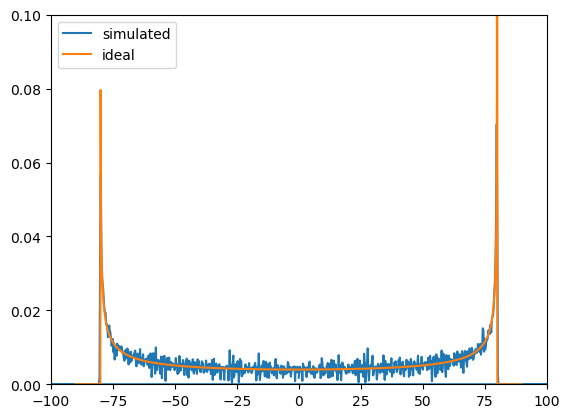

In [7]:
fc = 4E3
fs = 2e3
dop = jakes_doppler_zheng_xiao(fs, fd, 256)

t = np.arange(0.0, 106, 1/(fc))

y = dop.evaluate(t)
print(y.size)

f, P = sp.signal.welch(
    y,
    fs=fc,
    nperseg=2**14,
    noverlap=2**13,
    return_onesided=False,
    scaling="density"
)

f_test= np.arange(-fd-10, fd+10.1, 0.1)
y_ideal = class_PDS(f_test, fd)

plt.figure()
plt.plot(f, P, label="simulated")
plt.plot(f_test, y_ideal, label="ideal")
plt.xlim(-100, 100)
plt.ylim(0, 0.1)
plt.legend()
print(fd)

Text(0.5, 1.0, '100kHz vs 10kHz simulation of doppler for 80Hz')

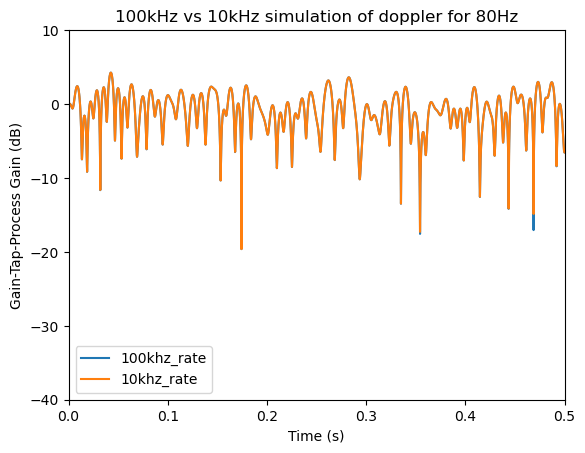

In [8]:
# interpolation validation/comparison
fs1 = 100E3
fs2 = 10.0E3
dop_full_rate = jakes_doppler_zheng_xiao(fs1, fd, 256)
dop_interp = jakes_doppler_zheng_xiao(fs2, fd, 256)
t1 = np.arange(0.0, 1, 1/fs1)
t2 = np.arange(0.0, 1, 1/fs2)

y1 = dop_full_rate.evaluate(t1)
y2 = dop_full_rate.evaluate(t2)

plt.figure()
plt.plot(t1, 10*np.log10(np.abs(y1) + 1E-300), label="100khz_rate")
plt.plot(t2, 10*np.log10(np.abs(y2) + 1E-300), label="10khz_rate")
plt.legend()
plt.xlim(0, 0.5)
plt.ylabel("Gain-Tap-Process Gain (dB)")
plt.xlabel("Time (s)")
plt.ylim(-40, 10)
plt.title("100kHz vs 10kHz simulation of doppler for 80Hz")

## Interpolation/upsampling Filters
- As noted above, rejection of spectral images at multiples of 80khz (1/144th rate) and 960khz (1/12th) need strong rejection as the cross modulate with the original signal and leave a mess when a channel simulator is supposed to be white-gloved
- The follow section is just code for my generation of the filters and the checks to make sure the passband is flat in the doppler region

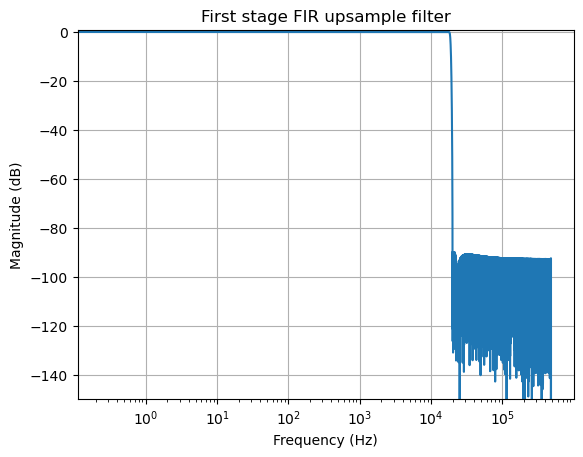

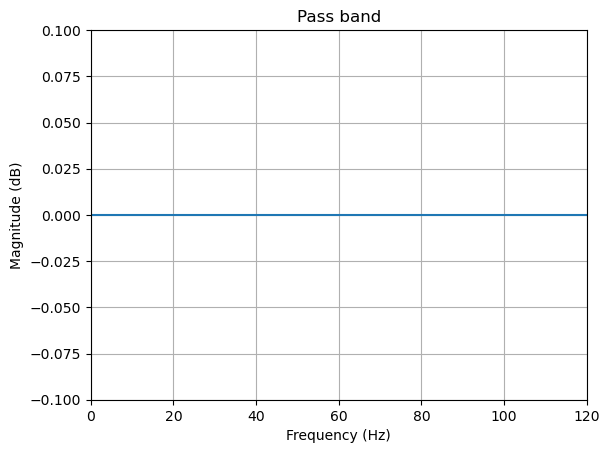

In [9]:
# Generate interpolation fir
import scipy as sp
fs_low = 80_000
fs = 11_520_000 / 12
l_inter = sp.signal.remez(4096, [0, 17_500, 20_000, fs/2], [1, 0], weight=[1, 100], fs=fs)
#fs = 11_520_000.0 / 12
#l_inter = sp.signal.remez(8192, [0, 8500, 9600, fs/2], [1, 0], weight=[1, 100], fs=fs) 

dc_gain = np.sum(l_inter)
l_inter /= dc_gain
N_fft = 2**22
H = sp.fft.rfft(l_inter, N_fft)
f = sp.fft.rfftfreq(N_fft, d=1/fs)

plt.figure()
plt.semilogx(f, 10*np.log10(np.abs(H) + 1e-120))
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.title("First stage FIR upsample filter")
plt.grid(True)
plt.ylim(-150, 1)
plt.show()

plt.figure()
plt.plot(f, 10*np.log10(np.abs(H) + 1e-120))
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.title("Pass band")
plt.grid(True)
plt.xlim(0, 120)
plt.ylim(-.1, .1)
plt.show()

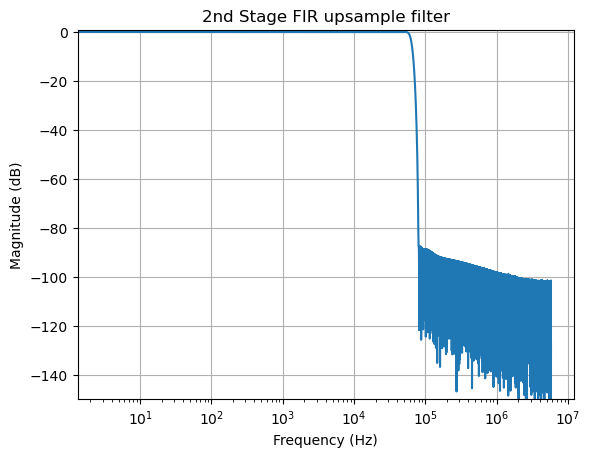

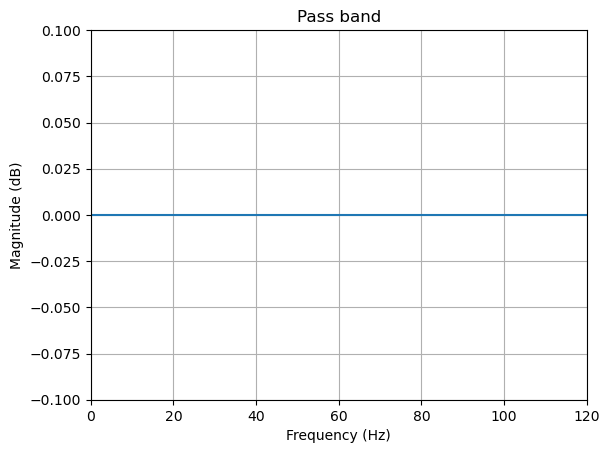

In [10]:
fs_low = fs2
fs = 11_520_000
#l_inter2 = sp.signal.firwin(4096, cutoff=80_000, window=("kaiser", 7.9), fs=fs)
l_inter2 = sp.signal.remez(4096, [0, 48_000, 80_000, fs/2], [1, 0], weight=[1, 100], fs=fs)
dc_gain = np.sum(l_inter2)
l_inter2 /= dc_gain
N_fft = 2**22
H = sp.fft.rfft(l_inter2, N_fft)
f = sp.fft.rfftfreq(N_fft, d=1/fs)

plt.figure()
plt.semilogx(f, 10*np.log10(np.abs(H) + 1e-120))
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.title("2nd Stage FIR upsample filter")
plt.grid(True)
plt.ylim(-150, 1)
plt.show()

plt.figure()
plt.plot(f, 10*np.log10(np.abs(H) + 1e-120))
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.title("Pass band")
plt.grid(True)
plt.xlim(0, 120)
plt.ylim(-.1, .1)
plt.show()

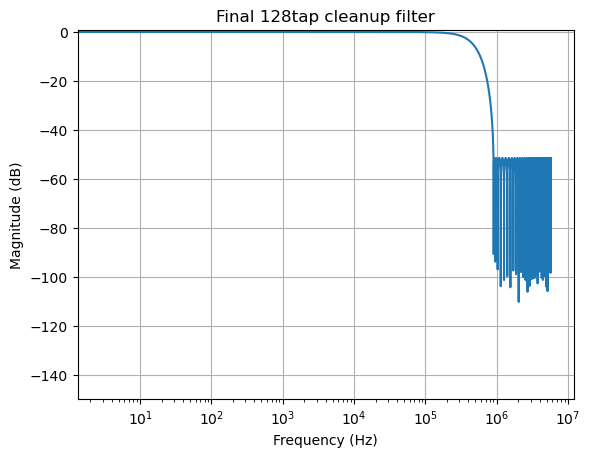

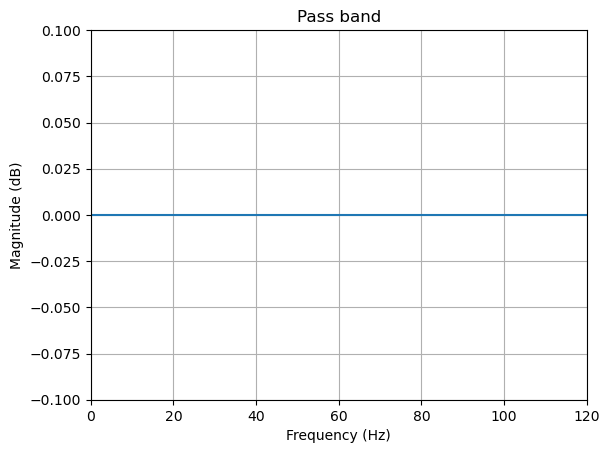

In [11]:
fs = 11_520_000
l_clean = sp.signal.remez(65, [0, 30_000, 900_000, fs/2], [1, 0], weight=[1, 100], fs=fs)
dc_gain = np.sum(l_clean)
l_clean /= dc_gain
N_fft = 2**22
H = sp.fft.rfft(l_clean, N_fft)
f = sp.fft.rfftfreq(N_fft, d=1/fs)

plt.figure()
plt.semilogx(f, 10*np.log10(np.abs(H) + 1e-120))
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.title("Final 128tap cleanup filter")
plt.grid(True)
plt.ylim(-150, 1)
plt.show()

plt.figure()
plt.plot(f, 10*np.log10(np.abs(H) + 1e-120))
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.title("Pass band")
plt.grid(True)
plt.xlim(0, 120)
plt.ylim(-.1, .1)
plt.show()

## Filter Result
- 180dB rejection at 80khz images up to 960khz
- 960khz images only has 150db rejection (but this is almost out of band
- Zero ripple in band
  1. 4096 taps at 1/12th rate
  2. 4096 taps at full rate
  3. 46 cleanup taps
- The primary issue I had was compensating for group delay as I wanted to compare to the base rate signal, so I had to play around with the last cleanup filter in terms of taps such that the group delay is an integer number of samples at the base sample rate
- That is really important otherwise its not feasible to compensate for group delay exactly without fractional resampling of some sort

## Validating the statistics of the Rayleigh fading simulator with interpolation
- In order to use the result code the behaviour and statistics of the resulting complex gain need to be check against the expected and the base rate to ensure that interpolation did not degrade anything seriouslly

The follow checks are done in order as follows:
1. PSD verification of spectral image rejection
2. Comparision of complex envelope at interpolated vs base rates
3. Ensuring group delay is compensated to ensure data aligns with anyones implementation given the same seed
4. measureing of autocoorelation function (ACF) against ideal (J0) bessel function for base 80khz rate
5. measureing of autocoorelation function (ACF) against ideal (J0) bessel function for full interpolation 11.52Mhz rate
6. Calculation of statistics for real, imaginary -> gaussian zero mean, envelope -> rayleigh distrubtion, power envelop -> exponential distrubtion

In [12]:
import src.tetraphymac.ch_simulator as tetraCh
ss = np.random.SeedSequence(12345)

ray_sim = tetraCh.RayleighProcess(11_520_000, fd, ss, 264)
signal = np.ones(shape=2**24, dtype=np.complex128)

y_res = ray_sim.apply_complex_gain(signal)
print(y_res.size)

16777216


(-200.0, 0.0)

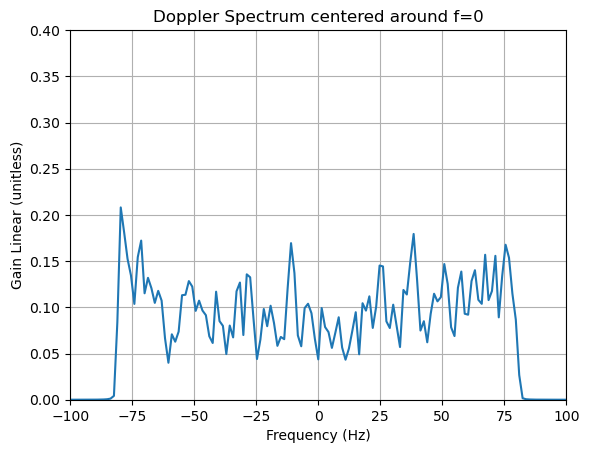

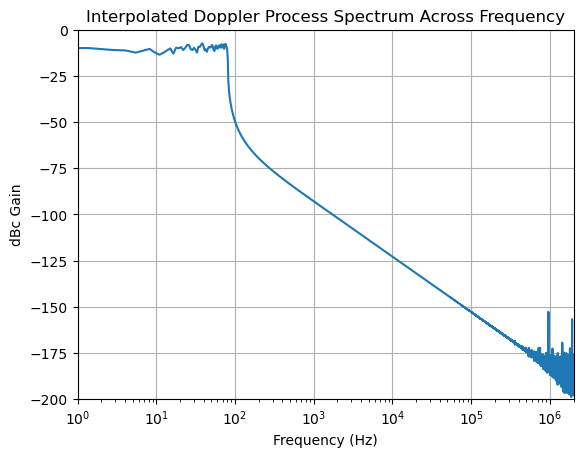

In [13]:
f, P = sp.signal.welch(
    y_res,
    fs=11_520_000.0,
    nperseg=2**23,
    noverlap=2**22,
    return_onesided=False,
    scaling="spectrum"
)
f = np.fft.fftshift(f)
P = np.fft.fftshift(P)
plt.figure()
plt.plot(f, np.sqrt(P), label="Interpolated")
plt.title("Doppler Spectrum centered around f=0")
plt.ylabel("Gain Linear (unitless)")
plt.xlabel("Frequency (Hz)")
plt.xlim(-100, 100)
plt.ylim(0, 0.4)
plt.grid()


# Wideband plotting
f, P = sp.signal.welch(
    y_res,
    fs=11_520_000.0,
    nperseg=2**23,
    noverlap=2**22,
    return_onesided=True,
    scaling="spectrum"
)
f = np.fft.fftshift(f)
P = np.fft.fftshift(P)
plt.figure()
plt.semilogx(f, 10*np.log10(np.sqrt(P) + 1E-300), label="Interpolated")
plt.xlim(1, 2E6)
plt.title("Interpolated Doppler Process Spectrum Across Frequency")
plt.ylabel("dBc Gain")
plt.grid()
plt.xlabel("Frequency (Hz)")
plt.ylim(-200, 0)

Text(0.5, 1.0, 'Base rate rayeligh fading gain (dB) vs interpolated gain with delay')

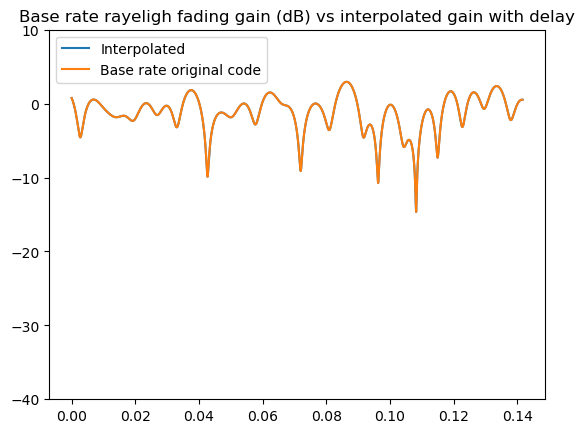

In [14]:
sample_n = 64*10*255*10
t = np.arange(0, sample_n) * (1/11_520_000)
ss = np.random.SeedSequence(12345)
ray_sim = tetraCh.RayleighProcess(11_520_000, fd, ss, 256)
signal = np.ones(shape=sample_n, dtype=np.complex128)
y_s = ray_sim.apply_complex_gain(signal)



# Original code at base rate:
fsim = 11_520_000
sample_base_rate_n = sample_n
dop = jakes_doppler_zheng_xiao(fsim, fd, 256, 12345)
tsim = np.arange(0, sample_base_rate_n) * (1/fsim)
y_o = dop.evaluate(tsim)

fsim2 = 80_000
sample_base_rate_n = sample_n // 144
dop2 = jakes_doppler_zheng_xiao(fsim, fd, 256, 12345)
tsim2 = np.arange(0, sample_base_rate_n) * (1/fsim2)
y_l = dop2.evaluate(tsim2)

plt.figure()
plt.plot(t, 10*np.log10(np.abs(y_s) + 1E-300), label="Interpolated")
#plt.plot(tsim, 10*np.log10(np.abs(y_o) + 1E-300), label=" 11.52MHz original code")
plt.plot(tsim2, 10*np.log10(np.abs(y_l) + 1E-300), label="Base rate original code")
plt.legend()
plt.ylim(-40, 10)
plt.title("Base rate rayeligh fading gain (dB) vs interpolated gain with delay")

Text(0.5, 1.0, 'Interpolated error')

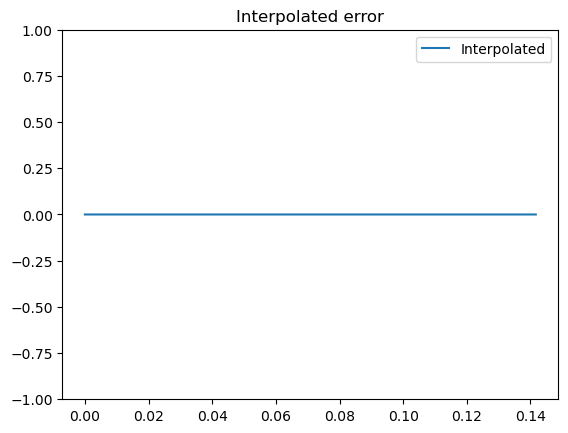

In [15]:
plt.figure()
error = (y_s/y_o)
plt.plot(t, 10*np.log10(np.abs(error) + 1E-300), label="Interpolated")
plt.legend()
plt.ylim(-1, 1)
plt.title("Interpolated error")

Lag = 0 samples
Lag = 0.000e+00 seconds


Text(0, 0.5, '|Cross-correlation|')

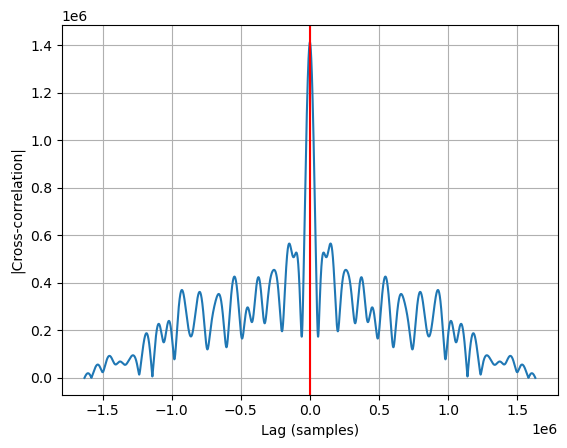

In [16]:
corr = sp.signal.correlate(y_s, y_o, mode="full", method="fft")

lags = np.arange(-(len(y_o)-1), len(y_s))

lag = lags[np.argmax(np.abs(corr))]

print(f"Lag = {lag} samples")
print(f"Lag = {lag / 11_520_000:.3e} seconds")

plt.figure()
plt.plot(lags, np.abs(corr))
plt.axvline(lag, color='r')
plt.grid(True)
plt.xlabel("Lag (samples)")
plt.ylabel("|Cross-correlation|")

### Testing to Verify Null Advance and Repeatability
1. In some cases we may want to advance the "absolute" time of the simulator but not transmit actual data in the slot.
    - In this case we perform a null_advance(n), where we advance the internal state of the process by n full_rate samples
    - The process internally just keeps track of where we would be but does not generate and interpolate new data, to save on computation
    - The next time a regular next() is called, it determine the state the process should be in and generates data up to that point such that the process is continous and time-aliagned without transisents compared to if we had ran it during the null_advance sample time

2. Repeatability
- In many cases we may wish the transmit the same burst over and over again or a different burst with the same EXACT same fading charactersitics, in this case we want **repeatability**
- In this case the process internally just does not increment state at all, and also restore interpolation memories such that if we
    1. Call next(n, repeatable = True) on sample A
    2. Call next(n) on sample B
- Both sample A and sample B would have the same complex gain applied to them.
- This type of behavior does not apply to null_advance(n), because in that case just dont call it
- It does however apply if we were in a null_advance previous to the point where we have no buffer samples, then if you want to "test" the waters and do next(n, repeatable = True) it will resume state as described in Part 1. but, it will not save/increment anything, so you could then do a null_advance(n) instead, perhaps not the most useful functionality but provides edge case coverage

Before Null Raysim A: sample_idx: 3559
Before Null Raysim A: buffer: 96
Null Raysim A: sample_idx: 4070
Null Raysim A: fractional_idc: 132
Null Raysim A: buffer: 0
After Raysim A: sample_idx: 7445
After Raysim A: fractional_idc: 0
After Raysim A: buffer: 108

Before Null Raysim B: sample_idx: 3559
Before Null Raysim B: buffer: 96
Null Raysim B: sample_idx: 4071
Null Raysim B: fractional_idc: 0
Null Raysim B: buffer: 12
After Raysim B: sample_idx: 7445
After Raysim B: fractional_idc: 0
After Raysim B: buffer: 108


(-0.1, 0.1)

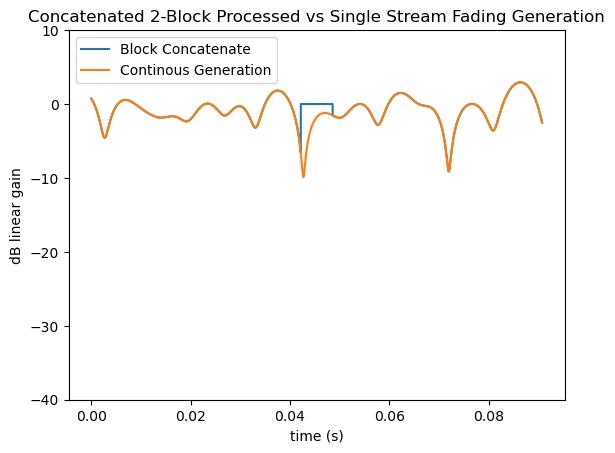

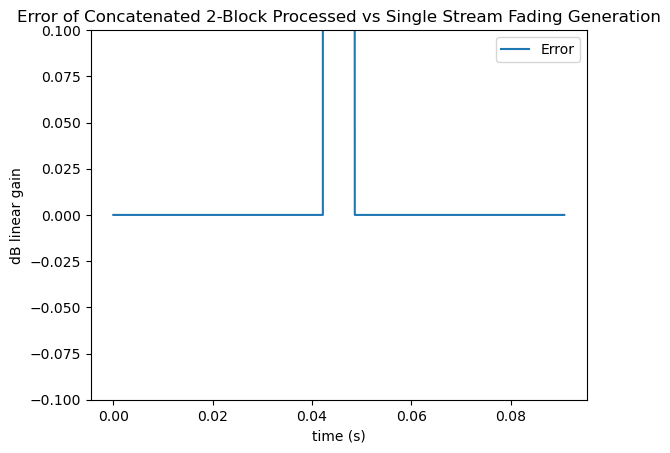

In [17]:
# Need to verifiy block process continuity for ChannelSimulator
sample_n = 64*10*253*3
null_time = 73812
t1 = np.arange(0, ((sample_n*2) + null_time)) * (1/11_520_000)
ss = np.random.SeedSequence(12345)
ray_sim_a = tetraCh.RayleighProcess(11_520_000, fd, ss, 256)
signal = np.ones(shape=sample_n, dtype=np.complex128)
y_a_1 = ray_sim_a.apply_complex_gain(signal)
print(f"Before Null Raysim A: sample_idx: {ray_sim_a._sample_idx}")
print(f"Before Null Raysim A: buffer: {ray_sim_a._buffer_len}")
y_a_2 = np.ones(shape=null_time, dtype=np.complex128)
ray_sim_a.null_advance(null_time)
print(f"Null Raysim A: sample_idx: {ray_sim_a._sample_idx}")
print(f"Null Raysim A: fractional_idc: {ray_sim_a._sample_frac_idx}")
print(f"Null Raysim A: buffer: {ray_sim_a._buffer_len}")
y_a_3 = ray_sim_a.apply_complex_gain(signal)
print(f"After Raysim A: sample_idx: {ray_sim_a._sample_idx}")
print(f"After Raysim A: fractional_idc: {ray_sim_a._sample_frac_idx}")
print(f"After Raysim A: buffer: {ray_sim_a._buffer_len}")
y_a = np.concatenate((y_a_1, y_a_2, y_a_3))

print("")

ss = np.random.SeedSequence(12345)
ray_sim_b = tetraCh.RayleighProcess(11_520_000, fd, ss, 256)
signal = np.ones(shape=(sample_n), dtype=np.complex128)
null_time_signal = np.ones(shape=null_time, dtype=np.complex128)
y_b_1 = ray_sim_b.apply_complex_gain(signal)
print(f"Before Null Raysim B: sample_idx: {ray_sim_b._sample_idx}")
print(f"Before Null Raysim B: buffer: {ray_sim_b._buffer_len}")
y_b_2 = ray_sim_b.apply_complex_gain(null_time_signal)
print(f"Null Raysim B: sample_idx: {ray_sim_b._sample_idx}")
print(f"Null Raysim B: fractional_idc: {ray_sim_b._sample_frac_idx}")
print(f"Null Raysim B: buffer: {ray_sim_b._buffer_len}")
y_b_3 = ray_sim_b.apply_complex_gain(signal)
y_b = np.concatenate((y_b_1, y_b_2, y_b_3))
print(f"After Raysim B: sample_idx: {ray_sim_b._sample_idx}")
print(f"After Raysim B: fractional_idc: {ray_sim_b._sample_frac_idx}")
print(f"After Raysim B: buffer: {ray_sim_b._buffer_len}")
plt.figure()
plt.plot(t1, 10*np.log10(np.abs(y_a) + 1E-300), label="Block Concatenate")
#plt.plot(tsim, 10*np.log10(np.abs(y_o) + 1E-300), label=" 11.52MHz original code")
plt.plot(t1, 10*np.log10(np.abs(y_b) + 1E-300), label="Continous Generation")
plt.legend()
plt.ylim(-40, 10)
plt.title("Concatenated 2-Block Processed vs Single Stream Fading Generation")
plt.ylabel("dB linear gain")
plt.xlabel("time (s)")
plt.figure()

error = (y_a/y_b)
plt.title("Error of Concatenated 2-Block Processed vs Single Stream Fading Generation")
plt.plot(t1, 10*np.log10(np.abs(error) + 1E-300), label="Error")
plt.legend()
plt.ylabel("dB linear gain")
plt.xlabel("time (s)")
plt.ylim(-.1, .1)

(-0.1, 0.1)

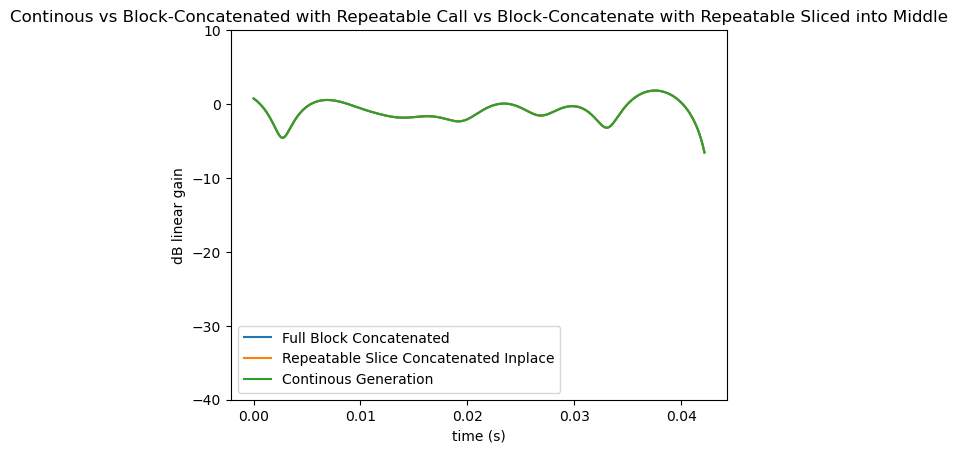

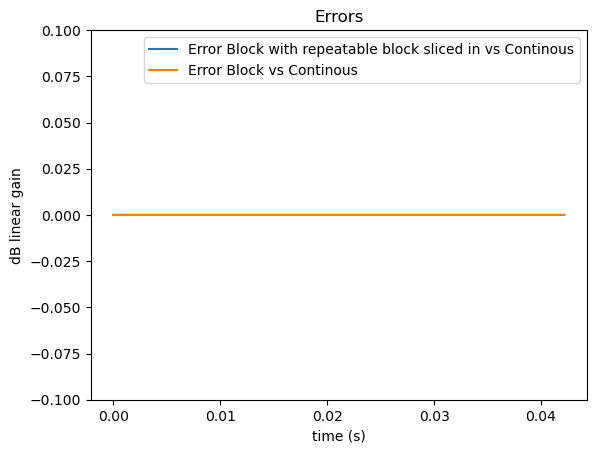

In [18]:
# Need to verifiy repeatability
sample_n = 64*10*253*1
t1 = np.arange(0, sample_n*3) * (1/11_520_000)
ss = np.random.SeedSequence(12345)
ray_sim_a = tetraCh.RayleighProcess(11_520_000, fd, ss, 256)
signal = np.ones(shape=sample_n, dtype=np.complex128)
y_a_1 = ray_sim_a.apply_complex_gain(signal)
y_a_2 = ray_sim_a.apply_complex_gain(signal, True)
y_a_discard = ray_sim_a.apply_complex_gain(signal)
y_a_3 = ray_sim_a.apply_complex_gain(signal)

y_a = np.concatenate((y_a_1, y_a_2, y_a_3))
y_a_prime = np.concatenate((y_a_1, y_a_discard, y_a_3))

ss = np.random.SeedSequence(12345)
ray_sim_b = tetraCh.RayleighProcess(11_520_000, fd, ss, 256)
signal = np.ones(shape=(sample_n*3), dtype=np.complex128)
y_b = ray_sim_b.apply_complex_gain(signal)

plt.figure()
plt.plot(t1, 10*np.log10(np.abs(y_a_prime) + 1E-300), label="Full Block Concatenated")
plt.plot(t1, 10*np.log10(np.abs(y_a) + 1E-300), label="Repeatable Slice Concatenated Inplace")
plt.plot(t1, 10*np.log10(np.abs(y_b) + 1E-300), label="Continous Generation")
plt.legend()
plt.ylim(-40, 10)
plt.title("Continous vs Block-Concatenated with Repeatable Call vs Block-Concatenate with Repeatable Sliced into Middle")
plt.ylabel("dB linear gain")
plt.xlabel("time (s)")
plt.figure()

error_1 = (y_a/y_b)
error_2 = (y_a_prime/y_b)
plt.title("Errors")
plt.plot(t1, 10*np.log10(np.abs(error_1) + 1E-300), label="Error Block with repeatable block sliced in vs Continous")
plt.plot(t1, 10*np.log10(np.abs(error_2) + 1E-300), label="Error Block vs Continous")
plt.legend()
plt.ylabel("dB linear gain")
plt.xlabel("time (s)")
plt.ylim(-.1, .1)

Before Null Raysim A: sample_idx: 1310
Before Null Raysim A: buffer: 80
Null Raysim A: sample_idx: 1822
Null Raysim A: fractional_idc: 4
Null Raysim A: buffer: 0
Repeatable After Raysim A: sample_idx: 1822
Repeatable After Raysim A: fractional_idc: 4
Repeatable After Raysim A: buffer: 0
After Raysim A: sample_idx: 2947
After Raysim A: fractional_idc: 0
After Raysim A: buffer: 76

After Raysim B: sample_idx: 2947
After Raysim B: fractional_idc: 0
After Raysim B: buffer: 76


(-0.1, 0.1)

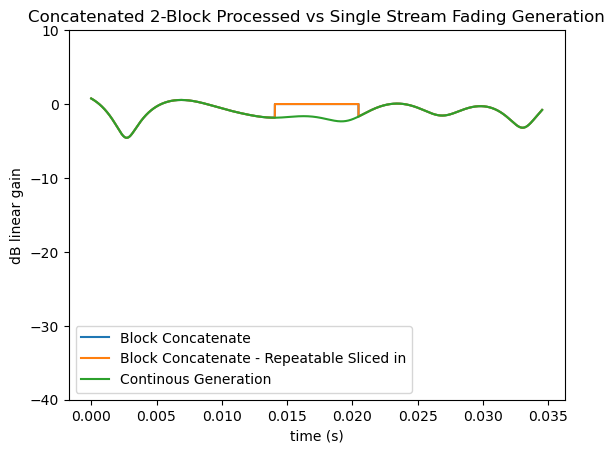

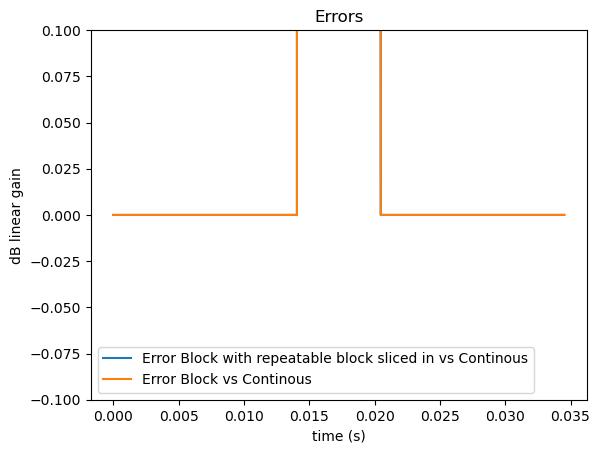

In [19]:
# Need to verifiy repeatability for null_advance then next()
sample_n = 64*10*253*1
null_time = 73812
t1 = np.arange(0, ((sample_n*2) + null_time)) * (1/11_520_000)
ss = np.random.SeedSequence(12345)
ray_sim_a = tetraCh.RayleighProcess(11_520_000, fd, ss, 256)
signal = np.ones(shape=sample_n, dtype=np.complex128)
y_a_1 = ray_sim_a.apply_complex_gain(signal)
print(f"Before Null Raysim A: sample_idx: {ray_sim_a._sample_idx}")
print(f"Before Null Raysim A: buffer: {ray_sim_a._buffer_len}")
y_a_2 = np.ones(shape=null_time, dtype=np.complex128)
ray_sim_a.null_advance(null_time)
print(f"Null Raysim A: sample_idx: {ray_sim_a._sample_idx}")
print(f"Null Raysim A: fractional_idc: {ray_sim_a._sample_frac_idx}")
print(f"Null Raysim A: buffer: {ray_sim_a._buffer_len}")
y_a_3_discard = ray_sim_a.apply_complex_gain(signal, True)
print(f"Repeatable After Raysim A: sample_idx: {ray_sim_a._sample_idx}")
print(f"Repeatable After Raysim A: fractional_idc: {ray_sim_a._sample_frac_idx}")
print(f"Repeatable After Raysim A: buffer: {ray_sim_a._buffer_len}")
y_a_3 = ray_sim_a.apply_complex_gain(signal)
print(f"After Raysim A: sample_idx: {ray_sim_a._sample_idx}")
print(f"After Raysim A: fractional_idc: {ray_sim_a._sample_frac_idx}")
print(f"After Raysim A: buffer: {ray_sim_a._buffer_len}")
y_a = np.concatenate((y_a_1, y_a_2, y_a_3))
y_a_prime = np.concatenate((y_a_1, y_a_2, y_a_3_discard))
print("")

ss = np.random.SeedSequence(12345)
ray_sim_b = tetraCh.RayleighProcess(11_520_000, fd, ss, 256)
signal = np.ones(shape=((sample_n*2) + null_time), dtype=np.complex128)
y_b = ray_sim_b.apply_complex_gain(signal)
print(f"After Raysim B: sample_idx: {ray_sim_b._sample_idx}")
print(f"After Raysim B: fractional_idc: {ray_sim_b._sample_frac_idx}")
print(f"After Raysim B: buffer: {ray_sim_b._buffer_len}")
plt.figure()
plt.plot(t1, 10*np.log10(np.abs(y_a) + 1E-300), label="Block Concatenate")
plt.plot(t1, 10*np.log10(np.abs(y_a_prime) + 1E-300), label="Block Concatenate - Repeatable Sliced in")
plt.plot(t1, 10*np.log10(np.abs(y_b) + 1E-300), label="Continous Generation")
plt.legend()
plt.ylim(-40, 10)
plt.title("Concatenated 2-Block Processed vs Single Stream Fading Generation")
plt.ylabel("dB linear gain")
plt.xlabel("time (s)")
plt.figure()

error_1 = (y_a/y_b)
error_2 = (y_a_prime/y_b)
plt.title("Errors")
plt.plot(t1, 10*np.log10(np.abs(error_1) + 1E-300), label="Error Block with repeatable block sliced in vs Continous")
plt.plot(t1, 10*np.log10(np.abs(error_2) + 1E-300), label="Error Block vs Continous")
plt.legend()
plt.ylabel("dB linear gain")
plt.xlabel("time (s)")
plt.ylim(-.1, .1)

### Results of testing RayleighProcess in terms of synchronization
- The interpolated version does have a delay originally compared to the base rate because of filtering however because this is a random process generated deterministically the starting point doesnt really matter, so I simpled shifted the delay to handle that, thus if compared to an externally generated code with the same seed, I get the same result.
- Both the repeatable and null_advance functionality works correctly and absolute state is always as expected and tracked well.

### Verifying RayleighProcess Statistics
- Need to verify after interpolation that:
1. I and Q i.i.d. : zero mean, variance of 0.5, normal distributed
2. Envelope is rayleigh distributed, mean of 1
3. Power nevelope is expontential distrubuted, mean of 1
4. Autocoorelation function matches that of bessel function of the 1st kind 0th order

0.015615384291539667
0.18543112328110845


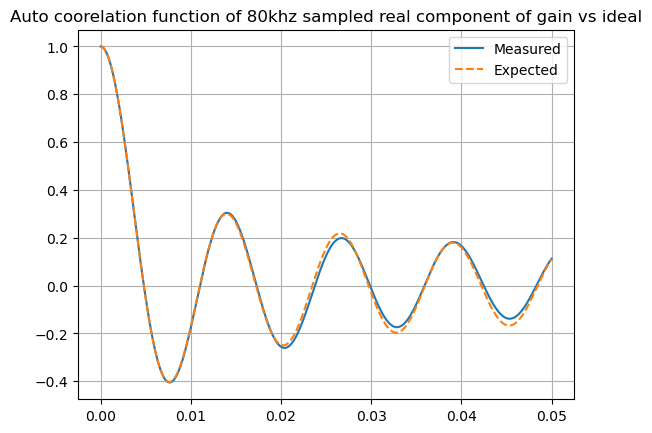

In [20]:
N = 2**18
signal = np.ones(shape=N, dtype=np.complex128)
ss = np.random.SeedSequence(12345)
ray_sim = tetraCh.RayleighProcess(11_520_000, fd, ss, 512)
g = ray_sim._generate(N)

R_meas = sp.signal.correlate(g, g, mode="full", method='fft')
R_meas = R_meas[N-1:]
lags = np.arange(N)
tau = lags / 80_000

R_meas /= (N - lags)
R_meas /= R_meas[0]
R_theory = sp.special.j0(2*np.pi*fd*tau)

tmax = 0.05
nplot = int(tmax * 80_000)
plt.figure()
plt.plot(tau[:nplot], np.real(R_meas[:nplot]), label='Measured')
plt.plot(tau[:nplot], R_theory[:nplot], "--", label='Expected')
plt.grid(True)
plt.title("Auto coorelation function of 80khz sampled real component of gain vs ideal")
plt.legend()

idx = tau <= 0.05      # first 50 ms
err = np.sqrt(np.mean(
    (np.real(R_meas[idx]) - R_theory[idx])**2
))
print(err)

idx = tau <= 0.05

real_rms = np.sqrt(np.mean(np.real(R_meas[idx])**2))
imag_rms = np.sqrt(np.mean(np.imag(R_meas[idx])**2))

print(imag_rms / real_rms)

0.00777296579832803
0.1750138902962431


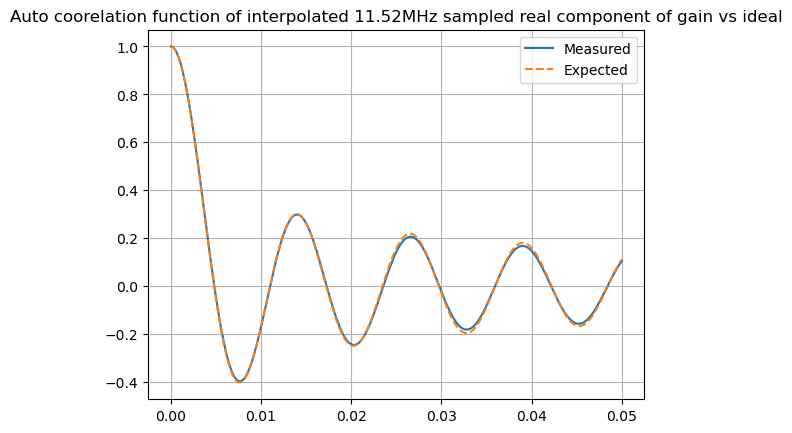

In [21]:
N = 2**26
signal = np.ones(shape=N, dtype=np.complex128)
ss = np.random.SeedSequence(12345)
ray_sim = tetraCh.RayleighProcess(11_520_000, fd, ss, 512)
g = ray_sim.apply_complex_gain(signal)

R_meas = sp.signal.correlate(g, g, mode="full", method='fft')
R_meas = R_meas[len(g)-1:]
R_meas /= np.arange(len(g), 0, -1)
R_meas /= R_meas[0]

tau = np.arange(len(R_meas))/11_520_000
R_theory = sp.special.j0(2*np.pi*fd*tau)

tmax = 0.05
nplot = int(tmax * 11_520_000)
plt.figure()
plt.plot(tau[:nplot], np.real(R_meas[:nplot]), label='Measured')
plt.plot(tau[:nplot], R_theory[:nplot], "--", label='Expected')
plt.title("Auto coorelation function of interpolated 11.52MHz sampled real component of gain vs ideal")
plt.grid(True)
plt.legend()

idx = tau <= 0.05      # first 50 ms
err = np.sqrt(np.mean(
    (np.real(R_meas[idx]) - R_theory[idx])**2
))
print(err)

idx = tau <= 0.05

real_rms = np.sqrt(np.mean(np.real(R_meas[idx])**2))
imag_rms = np.sqrt(np.mean(np.imag(R_meas[idx])**2))

print(imag_rms / real_rms)

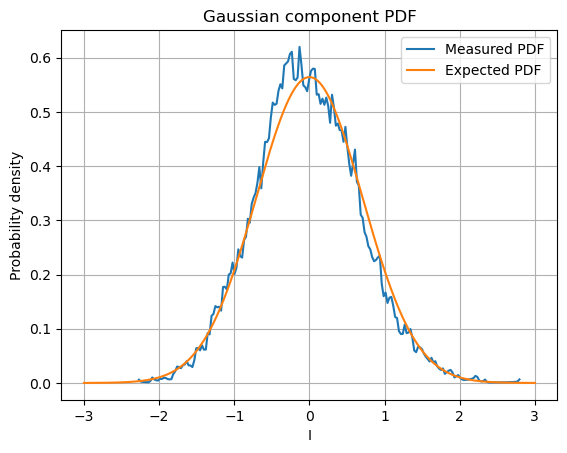

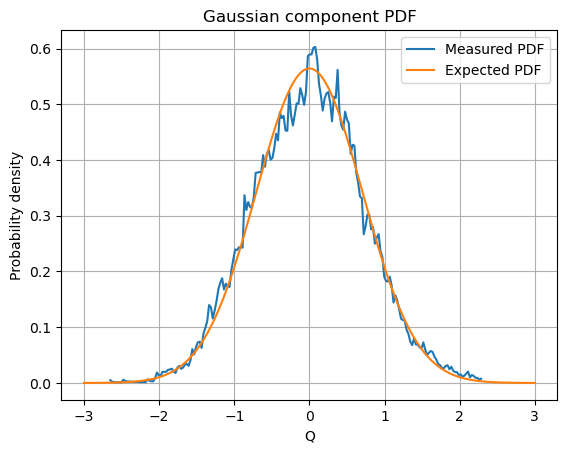

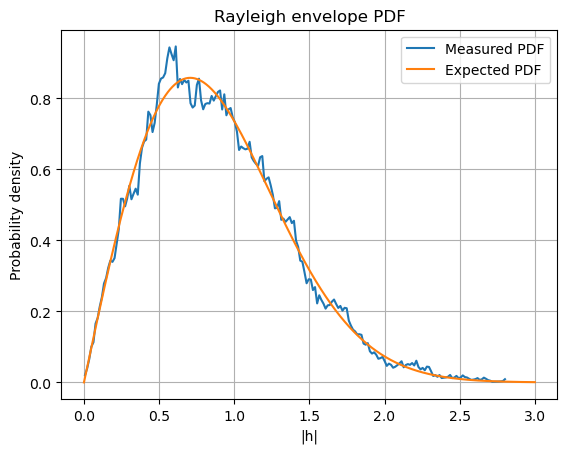

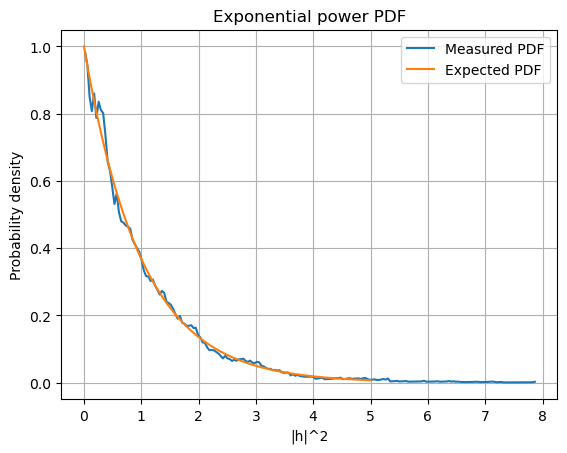

I mean: -0.02687889469444527
I var : 0.4772294147291452
Q mean: -0.007739741103875403
Q var : 0.531100377545825
Power: 1.0091121708473203


In [22]:
N = 2**26
signal = np.ones(shape=N, dtype=np.complex128)
ss = np.random.SeedSequence(12345)
ray_sim = tetraCh.RayleighProcess(11_520_000, fd, ss, 512)
g = ray_sim.apply_complex_gain(signal)

I = np.real(g)
Q = np.imag(g)
r = np.abs(g)
p = np.abs(g)**2

def plot_pdf(samples, expected_pdf, xlim, xlabel, title, bins=200):
    hist, edges = np.histogram(samples,bins=bins,density=True)
    centers = (edges[:-1] + edges[1:]) / 2
    plt.figure()
    plt.plot(centers,hist,label="Measured PDF")

    x = np.linspace(*xlim, 1000)
    
    plt.plot(x,expected_pdf(x),label="Expected PDF")
    plt.grid()
    plt.xlabel(xlabel)
    plt.ylabel("Probability density")
    plt.title(title)
    plt.legend()


plot_pdf(I,lambda x: sp.stats.norm.pdf(x,loc=0,scale=np.sqrt(0.5)),(-3,3),"I","Gaussian component PDF")
plot_pdf(Q,lambda x: sp.stats.norm.pdf(x,loc=0,scale=np.sqrt(0.5)),(-3,3),"Q","Gaussian component PDF")
plot_pdf(r,lambda x: sp.stats.rayleigh.pdf(x,scale=np.sqrt(0.5)),(0,3),"|h|","Rayleigh envelope PDF")
plot_pdf(p,lambda x: sp.stats.expon.pdf(x,scale=1),(0,5),"|h|^2","Exponential power PDF")
plt.show()


print("I mean:", np.mean(np.real(g)))
print("I var :", np.var(np.real(g)))
print("Q mean:", np.mean(np.imag(g)))
print("Q var :", np.var(np.imag(g)))
print("Power:", np.mean(np.abs(g)**2))

## Summary of Rayleigh fading
- The resulting statistics match well, the ACF (autocorrelation function) follow J(0), bessel function of the first kind of order zero, very well with only 0.77% error
- The component distrubtions are close to expectation, of course this is only one seed and not the result of an ensemble of implements
- Also the signal envelope tracks perfectly with the base sample rate one, meaning the interpolation handling and group delay compensation is right on
- Lastly, looking at the PSD the spectral images from upsampling are very minute and even hard to see with welch psd

# __Delay Control__
There are many methods for generating a fractional delay of sampled data. Of course when the sampling rate is smaller than the delay, the delay decomposes into a integer-sample delay and a fractional delay. For the TETRA simulation rate of 11.52 Msps, much of the delay is integer samples, for that portion of the delay, we simply shift the data in time w.r.t. to the original signal. 

To acheive a fractional delay, there are many ways to do that, Laakso, et al. `Splitting the Unit Delay: Tools for fractional delay filter design`, 1996, provides an exhaustive survey of contemprary methods to generate fractional delays. However, amoung the methods for fractional delay, the simplest is a Lagrange FIR delay.
## Lagrange Interpolator
The main limitation of the Lagrange FIR is it's narrowbanded response, which even with higher filter lengths (4-6) does not change much. Note that the lagrange polynomial interpolation is not stable/accurate for higher orders. 

Another limitation of the Lagrange FIR is that variable delay is not possible without recomputing the filter coefficents compared to Farrow FIR structures which are often used in real-time hw simulation or modems.

However, because the TETRA simulation rate is at 11.52Msps and the bw of interest is at the very most only 1/10th of that for harmonics and wideband noise, a Lagrange order 3, Length of 4, provides an acceptable usable bandwidth of 0.2.

If in the future a higher bandwidth, or lower sampling rate, is used then an alternative FIR filter design method would have to be used. For now the coefficents are defined as follows as taken from Laakso, et al.:
$$ h(n) = \prod_{\frac{k=0}{k\neq n}}^{N}\frac{D-k}{n-k}\, for\,   n=0,1,2,...N$$

In [23]:
def gen_lagrange_delay(D: float, N:int = 3):
    h_n = np.zeros(shape=N+1, dtype=np.float64)
    print(D)
    for n in range(N+1):
        n_k = 1
        k_vals = [x for x in range(N+1) if x != n]
        for k in k_vals:
            n_k *= ((D-k)/(n-k))
        h_n[n] = n_k
    return h_n

In [24]:
def split_delay(fs, delay, N):
    delay_total = (delay) * fs
    filter_int_delay = N/2

    int_delay = int(np.round(delay_total - filter_int_delay))
    filter_frac_delay = delay_total - int_delay - filter_int_delay

    if filter_frac_delay >= 0.5:
        int_delay += 1
        filter_frac_delay -= 1.0
    elif filter_frac_delay < -0.5:
        int_delay -= 1
        filter_frac_delay += 1.0

    filter_total_delay = filter_frac_delay + filter_int_delay
    h_coef = gen_lagrange_delay(filter_total_delay, N)

    return int_delay, h_coef


In [25]:
delay_us = 5.0E-6
fs = 11_520_000.0
int_delay, delay_h = split_delay(fs, delay_us, 3)
print(int_delay)
print(delay_h)

1.6000000000000014
56
[-0.056  0.448  0.672 -0.064]


Text(0, 0.5, 'Group delay error vs expected (us)')

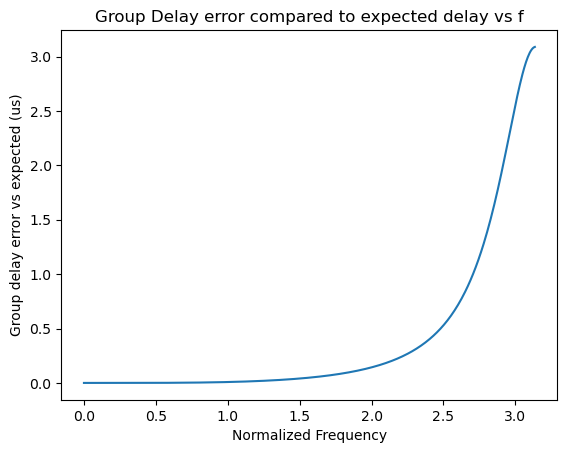

In [26]:
w, gd = sp.signal.group_delay((delay_h, 1))
plt.plot(w, gd-(1.6))
plt.title("Group Delay error compared to expected delay vs f")
plt.xlabel("Normalized Frequency")
plt.ylabel("Group delay error vs expected (us)")

## Verifiying the Implemented delay
- To verify the delay, lag will be calculated via convolution for a given delay

In [27]:
import src.tetraphymac.ch_simulator as tetraCh 
delay_us = 11.6E-6
fs = 11_520_000.0
int_delay, delay_h = tetraCh._calculate_delay_parameters(fs, delay_us)
print(int_delay)
print(delay_h)

132
[-0.05302733+0.j  0.41079398+0.j  0.70549402+0.j -0.06326067+0.j]


In [28]:
# generate test impulse function
test_signal = np.zeros(shape = 400, dtype=np.complex128)
test_signal = np.concatenate((test_signal, [1.0+0.0j]), axis=0)
test_signal = np.concatenate((test_signal, np.zeros(shape = 400, dtype=np.complex128)), axis=0)
print(np.sum(test_signal))
print(test_signal.size)

(1+0j)
801


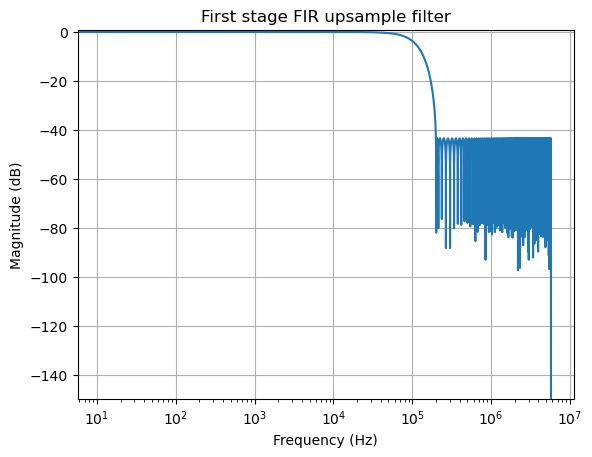

In [29]:
# Before filtering with delay filter, we must filter the signal to reduce the bandwidth to be accurate to intended signal bw instead of quasi impulse function
# Generate interpolation fir
l_filt = sp.signal.remez(256, [0, 20E3, 200E3, fs/2], [1, 0], weight=[1, 100], fs=fs)
dc_gain = np.sum(l_filt)
l_filt /= dc_gain
N_fft = 2**20
H = sp.fft.rfft(l_filt, N_fft)
f = sp.fft.rfftfreq(N_fft, d=1/fs)

plt.figure()
plt.semilogx(f, 10*np.log10(np.abs(H) + 1e-120))
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.title("First stage FIR upsample filter")
plt.grid(True)
plt.ylim(-150, 1)
plt.show()

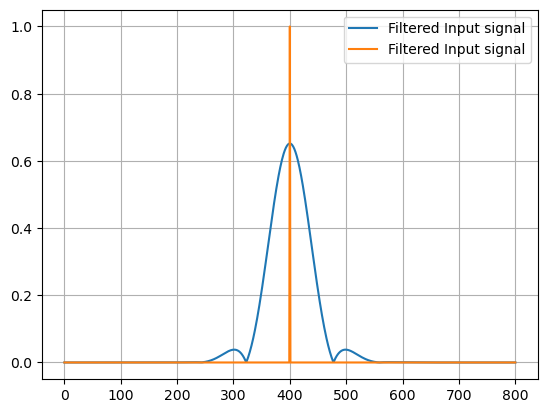

In [30]:
l_filt = np.complex128(l_filt)
input_sig = sp.signal.filtfilt(l_filt, [1.0], test_signal)
input_sig *= 50  # Give it some gain to make it easier to see
plt.figure()
plt.plot(np.abs(input_sig), label="Filtered Input signal")
plt.plot(np.abs(test_signal), label="Filtered Input signal")
plt.legend()
plt.grid()

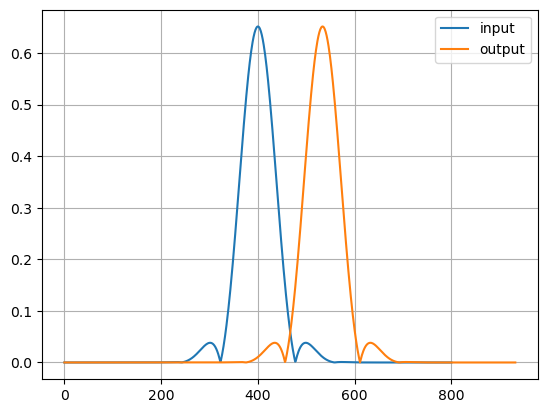

In [31]:
out_delay_int = np.zeros(shape=(int_delay + input_sig.size), dtype=np.complex128)
out_delay_int[int_delay:] = input_sig[:]

out = sp.signal.lfilter(delay_h, [1.0], out_delay_int)
plt.figure()
plt.plot(np.abs(input_sig), label="input")
plt.plot(np.abs(out), label="output")
plt.legend()
plt.grid(True)

Lag = 134000000.0 samples
Lag = 11.632 microseconds
Lag resolution limited to +/-0.08680555555555557 microseconds


Text(0, 0.5, '|Cross-correlation|')

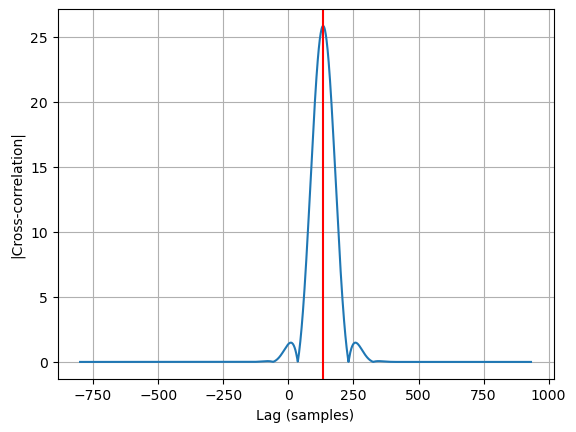

In [32]:
corr = sp.signal.correlate(out, input_sig, mode="full", method='direct')

lags = np.arange(-(len(input_sig)-1), len(out))

lag = lags[np.argmax(np.abs(corr))] * 1E6

print(f"Lag = {lag} samples")
print(f"Lag = {lag / fs:2.3f} microseconds")
print(f"Lag resolution limited to +/-{(1/fs)*1E6} microseconds")
plt.figure()
plt.plot(lags, np.abs(corr))
plt.axvline((lag/1E6), color='r')
plt.grid(True)
plt.xlabel("Lag (samples)")
plt.ylabel("|Cross-correlation|")

11.60000000009789


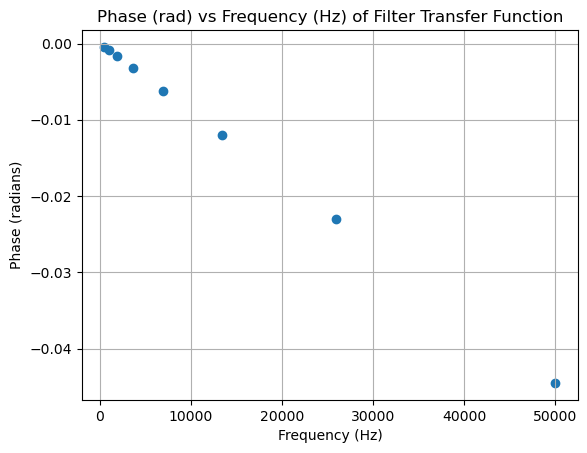

In [33]:
import src.tetraphymac.measurements as tetraMeas
delay_val = tetraMeas.measure_filter_group_delay(fs, None, delay_h, 5E2, 50E3, 8, True, True)
total_delay = ((delay_val) + np.float64(int_delay)) * (1/fs)
print(total_delay*1E6)

## Verification of Propagation Tap Delay Behaviour
- Propagation tap has many possible operation modes, thus a fair number of tests need to be done to ensure that is deterministic, has repeatbility if enable, and handles removing transisents and affecting the result signal as little as possible.
- Actual tetra test signals are used where possible, otherwise test signals that are within the BW and characteristics:
    - Start Bursts should be or equal near zero at the start (both I and Q)
    - End bursts should be equal or near zero at the end (both I and Q)
    - Isolated bursts should be windowed or behave as equal to zero at start in end (both I and Q)

In [48]:
import numpy as np
import src.tetraphymac.constants as tetraConstants
import src.tetraphymac.ch_simulator as tetraCh
custom_tap = tetraConstants.PropagationTapParameters(13.7E-6, 1.0, "STATIC")

test_tap1 = tetraCh.PropagationTap(11_520_000, 0.0, custom_tap, None)

fs = 11_520_000
f_c = 11.520E3
t = np.arange(0, 2000) * (1/fs)
phase = (np.pi)/4
test_signal = 1 + (np.sqrt(1/10))*np.cos(1*np.pi*f_c * t).astype(np.complex128)

def window_function(n):
    sps = 1
    k = np.arange((n-2)*sps, dtype=float64)
    profile = 0.5 * (1.0 - cos(pi * k / (((n-2)*sps)-1)))
    lut = profile.astype(float64)
    lut[0] = 0
    lut[-1] = 1
    return lut

window = window_function(202)
test_signal[:200] = test_signal[:200] * window
test_signal[-200:] = test_signal[-200:] * (1.0 - window)

Int buffer Before: [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
Added Startup Padding
Int buffer After: [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
Int delay: 156
Required History: 159
Filter Size: 4
2000
2159


Text(0.5, 1.0, "'Full' Mode delay output test")

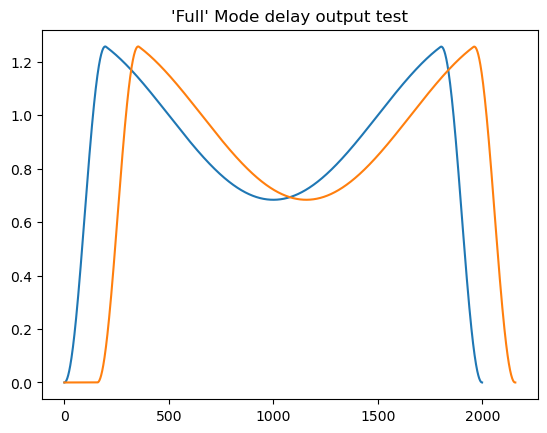

In [49]:
out = test_tap1.process(test_signal, test_signal.size, "ISOLATED", "full", True)
print(f"Int delay: {test_tap1.int_delay}")
print(f"Required History: {test_tap1.required_history}")
print(f"Filter Size: {test_tap1.h_delay_fir.size}")
print(test_signal.size)
print(out.size)
plt.figure()
plt.plot(np.abs(test_signal))
plt.plot(np.abs(out))
plt.title("'Full' Mode delay output test")

In [50]:
out = out[159:]

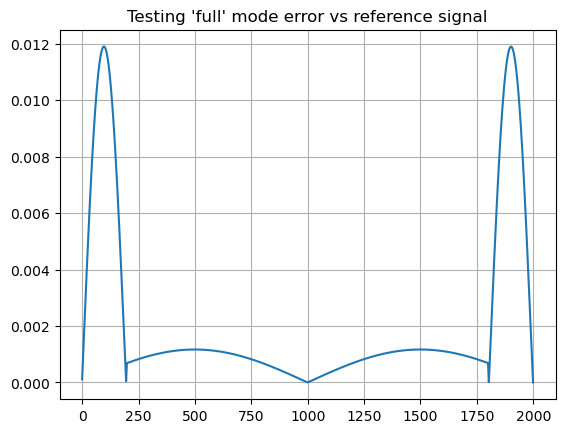

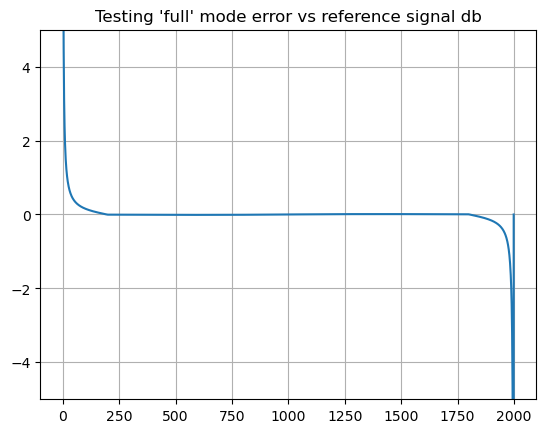

In [57]:
plt.figure()
plt.plot(np.abs(test_signal-out))
plt.title("Testing 'full' mode error vs reference signal")
plt.grid()

plt.figure()
error = 20*np.log10(np.abs(out) + 1e-300) - 20*np.log10(np.abs(test_signal) + 1e-300)
plt.plot(error)
plt.ylim(-5, 5)
plt.title("Testing 'full' mode error vs reference signal db")
plt.grid()
nmse = 10*np.log10(np.sum(np.abs(err)**2) / np.sum(np.abs(reference)**2))

Int buffer Before: [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
Added Startup Padding
Int buffer After: [1.1308289 +0.j 1.12471554+0.j 1.1184741 +0.j 1.11210615+0.j
 1.10561329+0.j 1.09899714+0.j 1.09225938+0.j 1.08540171+0.j
 1.07842584+0.j 1.07133356+0.j]
Before self.h_zi: [0.+0.j 0.+0.j 0.+0.j]
After self.h_zi: [ 1.17378828+0.j  0.95428103+0.j -0.050119  +0.j]
Int buffer Before: [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
Added Startup Padding
Int buffer After: [0.72099502+0.j 0.72052877+0.j 0.72006528+0.j 0.71960455+0.j
 0.71914659+0.j 0.71869141+0.j 0.718239  +0.j 0.71778937+0.j
 0.71734252+0.j 0.71689847+0.j]
Before self.h_zi: [0.+0.j 0.+0.j 0.+0.j]
After self.h_zi: [ 0.74234661+0.j  0.60576555+0.j -0.0318074 +0.j]
Int buffer Before: [0.72099502+0.j 0.72052877+0.j 0.72006528+0.j 0.71960455+0.j
 0.71914659+0.j 0.71869141+0.j 0.718239  +0.j 0.71778937+0.j
 0.71734252+0.j 0.71689847+0.j]
Int buffer After: [1.1308289 +0.j 1.12471

True

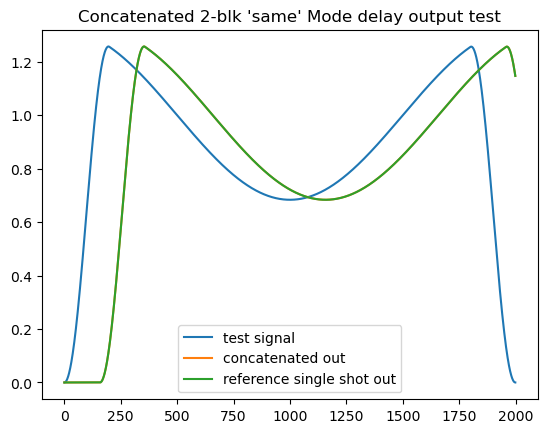

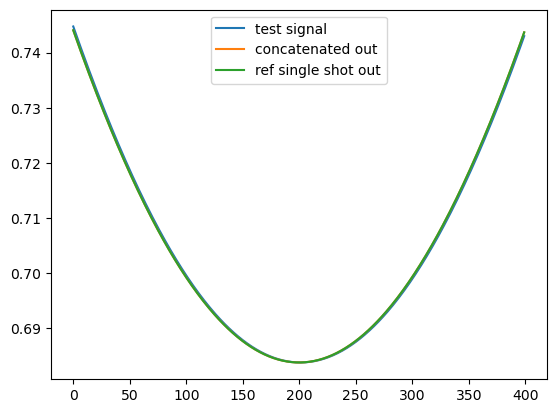

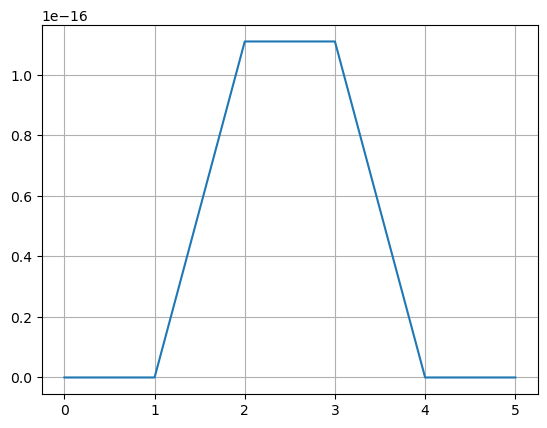

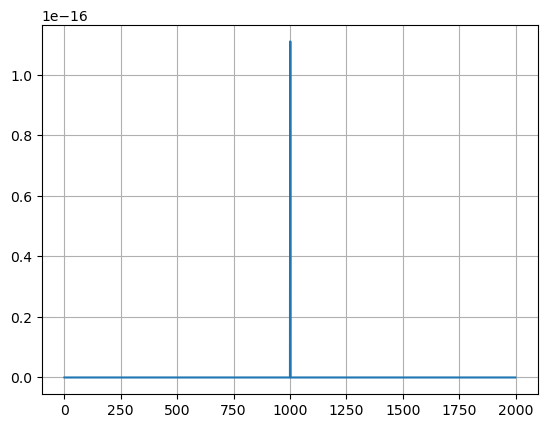

In [13]:
test_tap1 = tetraCh.PropagationTap(11_520_000, 0.0, custom_tap, None)
test_tap2 = tetraCh.PropagationTap(11_520_000, 0.0, custom_tap, None)
blk1 = test_signal.copy()[:1000]
blk2 = test_signal.copy()[1000:]
out_ref = test_tap2.process(test_signal, test_signal.size, "ISOLATED", "same", False)
out1 = test_tap1.process(blk1, blk1.size, "START", "same", False)
out2 = test_tap1.process(blk2, blk2.size, "END", "same", False)
out = np.concatenate((out1, out2))
print(test_signal.size)
print(out_ref.size)
print(out.size)
plt.figure()
plt.plot(np.abs(test_signal), label="test signal")
plt.plot(np.abs(out), label = "concatenated out")
plt.plot(np.abs(out_ref), label="reference single shot out")
plt.title("Concatenated 2-blk 'same' Mode delay output test")
plt.legend()


plt.figure()
start = 999
plt.plot(np.abs(test_signal)[start-200:start+200], label="test signal")
start += test_tap1.required_history
plt.plot(np.abs(out)[start-200:start+200], label = "concatenated out")
plt.plot(np.abs(out_ref)[start-200:start+200], label="ref single shot out")
plt.legend()
plt.figure()
plt.plot(np.abs(out_ref - out)[999: 1005])
plt.grid()
plt.figure()
plt.plot(np.abs(out_ref - out))
plt.grid()

# We may get a tiny, tiny error at the boundary but it seems to be within machine precision for the FIR calculations
# more importantly the states match when I printed them out
np.allclose(out_ref, out)

Int buffer Before: [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
Added Startup Padding
Int buffer After: [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
Added Post Tail Padding


Text(0.5, 0, 'Sample index')

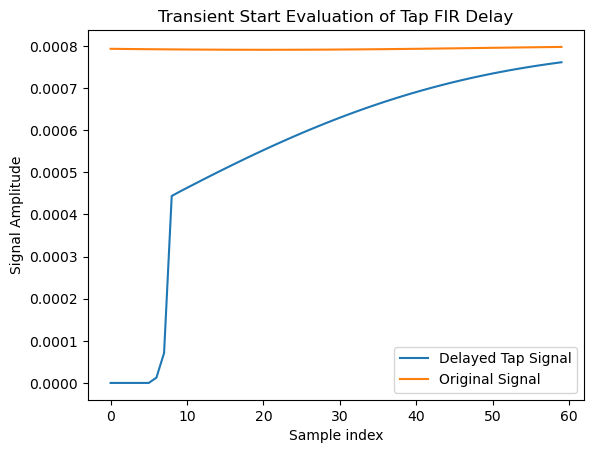

In [14]:
import src.tetraphymac.logical_channels as tetraLch
import src.tetraphymac.physical_channels as tetraPhy
import src.tetraphymac.transmitter as tetraTx
import src.tetraphymac.tx_rx_utilities as tetraUtil
import src.tetraphymac.constants as tetraConstants
import src.tetraphymac.measurements as tetraMeas
test_tap1 = tetraCh.PropagationTap(11_520_000, 0.0, custom_tap, None)
tx_real = tetraTx.RealTransmitter()
ul_tp_rf_channel = tetraPhy.PhysicalChannel(1, False, 905.1, 918.1, tetraPhy.PhyType.TRAFFIC_CHANNEL)
pkt_traffic_ch = tetraLch.TCH_4_8(n=4)
pkt_traffic_ch.encode_type5_bits(pkt_traffic_ch.generate_rnd_input(4))

ul_tp_burst = tetraPhy.NormalUplinkBurst(ul_tp_rf_channel, 1, 1, 1)
burst_modulation_bits = ul_tp_burst.construct_burst_sequence(pkt_traffic_ch)
rx_real = tx_real.transmit_burst(burst_modulation_bits,
                                 (ul_tp_burst.start_ramp_period, ul_tp_burst.end_ramp_period))

out2 = test_tap1.process(rx_real, rx_real.size, "ISOLATED", "full", True)
plt.figure()
plt.plot(np.abs(out2)[150:210], label="Delayed Tap Signal")
plt.plot(np.abs(rx_real)[150:210], label="Original Signal")
plt.title("Transient Start Evaluation of Tap FIR Delay")
plt.legend()
plt.ylabel("Signal Amplitude")
plt.xlabel("Sample index")

Int buffer Before: [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
Added Startup Padding
Int buffer After: [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
Added Post Tail Padding


Text(0.5, 0, 'Sample index')

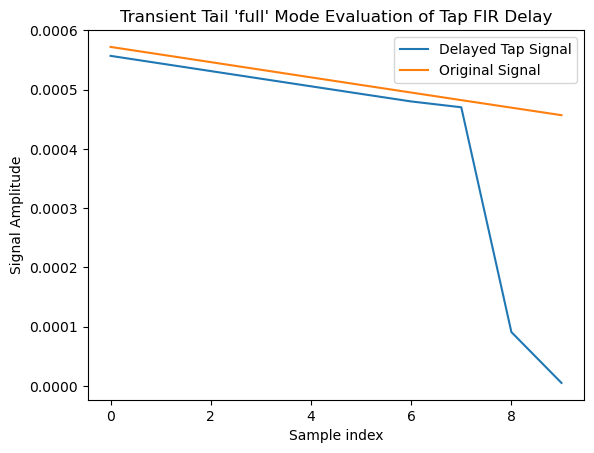

In [15]:
import src.tetraphymac.logical_channels as tetraLch
import src.tetraphymac.physical_channels as tetraPhy
import src.tetraphymac.transmitter as tetraTx
import src.tetraphymac.tx_rx_utilities as tetraUtil
import src.tetraphymac.constants as tetraConstants
import src.tetraphymac.measurements as tetraMeas
test_tap1 = tetraCh.PropagationTap(11_520_000, 0.0, custom_tap, None)

tx_real = tetraTx.RealTransmitter()
ul_tp_rf_channel = tetraPhy.PhysicalChannel(1, False, 905.1, 918.1, tetraPhy.PhyType.TRAFFIC_CHANNEL)
pkt_traffic_ch = tetraLch.TCH_4_8(n=4)
pkt_traffic_ch.encode_type5_bits(pkt_traffic_ch.generate_rnd_input(4))

ul_tp_burst = tetraPhy.NormalUplinkBurst(ul_tp_rf_channel, 1, 1, 1)
burst_modulation_bits = ul_tp_burst.construct_burst_sequence(pkt_traffic_ch)
rx_real = tx_real.transmit_burst(burst_modulation_bits,
                                 (ul_tp_burst.start_ramp_period, ul_tp_burst.end_ramp_period))

out2 = test_tap1.process(rx_real, rx_real.size, "ISOLATED", "full", True)
plt.figure()
plt.plot(np.abs(out2[-10:]), label="Delayed Tap Signal")
plt.plot(np.abs(rx_real[-10:]), label="Original Signal")
plt.title("Transient Tail 'full' Mode Evaluation of Tap FIR Delay")
plt.legend()
plt.ylabel("Signal Amplitude")
plt.xlabel("Sample index")

Int buffer Before: [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
Added Startup Padding
Int buffer After: [-0.00038895-0.0007859j  -0.00038938-0.00078571j -0.0003898 -0.00078552j
 -0.00039022-0.00078534j -0.00039063-0.00078515j -0.00039104-0.00078497j
 -0.00039145-0.00078478j -0.00039186-0.0007846j  -0.00039226-0.00078442j
 -0.00039266-0.00078424j]
Before self.h_zi: [0.+0.j 0.+0.j 0.+0.j]
After self.h_zi: [-3.99214218e-04-8.08587726e-04j -3.26243914e-04-6.60041983e-04j
  1.71287389e-05+3.46565883e-05j]
Int buffer Before: [-0.00038895-0.0007859j  -0.00038938-0.00078571j -0.0003898 -0.00078552j
 -0.00039022-0.00078534j -0.00039063-0.00078515j -0.00039104-0.00078497j
 -0.00039145-0.00078478j -0.00039186-0.0007846j  -0.00039226-0.00078442j
 -0.00039266-0.00078424j]
Added Delay Buffer Tail Padding
Int buffer After: [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
Before self.h_zi: [-3.99214218e-04-8.08587726e-04j -3.26243914e-04-6.60041983e-04

Text(0.5, 0, 'Sample index')

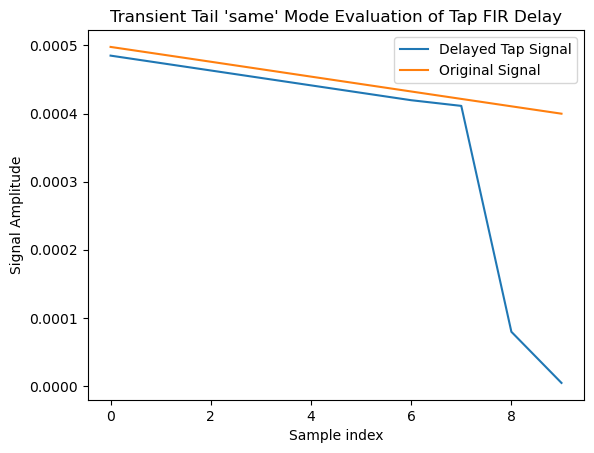

In [16]:
import src.tetraphymac.logical_channels as tetraLch
import src.tetraphymac.physical_channels as tetraPhy
import src.tetraphymac.transmitter as tetraTx
import src.tetraphymac.tx_rx_utilities as tetraUtil
import src.tetraphymac.constants as tetraConstants
import src.tetraphymac.measurements as tetraMeas
test_tap1 = tetraCh.PropagationTap(11_520_000, 0.0, custom_tap, None)
np.random.seed(10)
tx_real = tetraTx.RealTransmitter()
ul_tp_rf_channel = tetraPhy.PhysicalChannel(1, False, 905.1, 918.1, tetraPhy.PhyType.TRAFFIC_CHANNEL)
pkt_traffic_ch = tetraLch.TCH_4_8(n=4)
pkt_traffic_ch.encode_type5_bits(pkt_traffic_ch.generate_rnd_input(4))

ul_tp_burst = tetraPhy.NormalUplinkBurst(ul_tp_rf_channel, 1, 1, 1)
burst_modulation_bits = ul_tp_burst.construct_burst_sequence(pkt_traffic_ch)
rx_real = tx_real.transmit_burst(burst_modulation_bits,
                                 (ul_tp_burst.start_ramp_period, ul_tp_burst.end_ramp_period))

out2 = test_tap1.process(rx_real, rx_real.size, "ISOLATED", "same")
null_zeros = np.zeros(shape=400, dtype=np.complex128)
out3 = test_tap1.process(null_zeros, 400, "END", "same")
print(out3.size)
out2 = np.concatenate((out2, out3[:test_tap1.required_history]))
plt.figure()
plt.plot(np.abs(out2[-10:]), label="Delayed Tap Signal")
plt.plot(np.abs(rx_real[-10:]), label="Original Signal")
plt.title("Transient Tail 'same' Mode Evaluation of Tap FIR Delay")
plt.legend()
plt.ylabel("Signal Amplitude")
plt.xlabel("Sample index")

## Results of delay implementation
- The lagrange FIR fractional delay was correctly observed using both coorelation(within measurement uncertainity) and precisely via phase unwrapping methods
- The combination of integer delay and filter yield the correct delay for within the design bandwidth (10% of fs = 1.152MHz)